# Assignment 1: Neural Networks
## IMDB Movie Review Classification

In [1]:
# Import required libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Load the IMDB movie review dataset
from tensorflow.keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

print("Number of training samples:", len(train_data))
print("Number of test samples:", len(test_data))

print("\nFirst training review:")
print(train_data[0])

print("\nLabel of first training review:")
print(train_labels[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of training samples: 25000
Number of test samples: 25000

First training review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38

## 1. Data Preparation

In [4]:
# Convert the reviews into 10,000-dimensional binary vectors
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

# Vectorize training and test data
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# Convert labels to floating-point values
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

# Check the resulting shapes
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (25000, 10000)
x_test shape: (25000, 10000)
y_train shape: (25000,)
y_test shape: (25000,)


In [5]:
# Create a validation set using the first 10,000 training samples
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

# Check the sizes
print("Training samples:", partial_x_train.shape)
print("Validation samples:", x_val.shape)
print("Test samples:", x_test.shape)

Training samples: (15000, 10000)
Validation samples: (10000, 10000)
Test samples: (25000, 10000)


## 2. Baseline Model

In [6]:
# Build the baseline neural network
model_baseline = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")])

# Compile the model
model_baseline.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

# Display the model architecture
model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the baseline model for 20 epochs
history_baseline = model_baseline.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.7593 - loss: 0.6120 - val_accuracy: 0.8283 - val_loss: 0.5154
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8692 - loss: 0.4250 - val_accuracy: 0.8701 - val_loss: 0.3776
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8983 - loss: 0.3130 - val_accuracy: 0.8676 - val_loss: 0.3358
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9148 - loss: 0.2512 - val_accuracy: 0.8792 - val_loss: 0.3019
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9285 - loss: 0.2110 - val_accuracy: 0.8840 - val_loss: 0.2848
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.9393 - loss: 0.1807 - val_accuracy: 0.8849 - val_loss: 0.2828
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.9489 - loss: 0.1562 - val_accuracy: 0.8693 - val_loss: 0.3300
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.9547 - loss: 0.1379 - val_accuracy: 0.8859 -

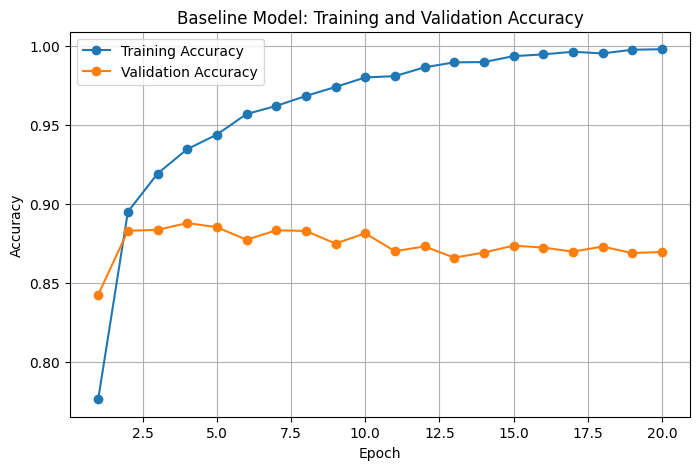

In [ ]:
# Extract training history
history_dict = history_baseline.history

accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]
loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

epochs = range(1, len(accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, "o-", label="Training Accuracy")
plt.plot(epochs, val_accuracy, "o-", label="Validation Accuracy")
plt.title("Baseline Model: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

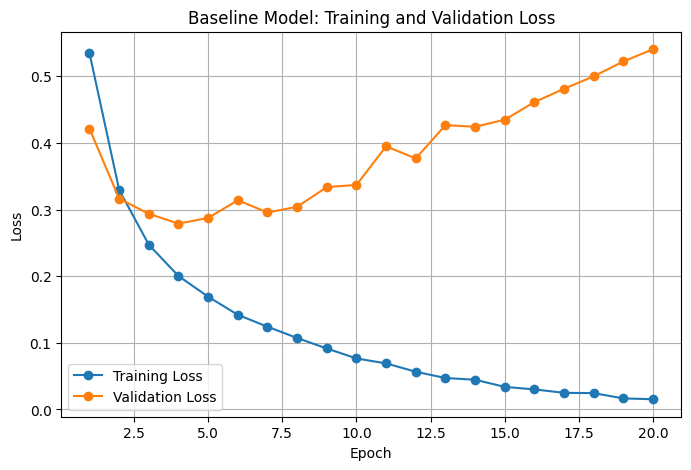

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, "o-", label="Training Loss")
plt.plot(epochs, val_loss, "o-", label="Validation Loss")
plt.title("Baseline Model: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Find the epoch with the highest validation accuracy
best_epoch_acc = np.argmax(val_accuracy) + 1
best_val_acc = np.max(val_accuracy)

# Find the epoch with the lowest validation loss
best_epoch_loss = np.argmin(val_loss) + 1
best_val_loss = np.min(val_loss)

print("Best validation accuracy:")
print(f"Epoch {best_epoch_acc}: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

print("\nLowest validation loss:")
print(f"Epoch {best_epoch_loss}: {best_val_loss:.4f}")

Best validation accuracy:
Epoch 4: 0.8880 (88.80%)

Lowest validation loss:
Epoch 4: 0.2790


## 3. Effect of Number of Hidden Layers

In [ ]:
# Model with ONE hidden layer
model_1layer = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")])

model_1layer.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model_1layer.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,033 (625.13 KB)

 Trainable params: 160,033 (625.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with ONE hidden layer
history_1layer = model_1layer.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7977 - loss: 0.5051 - val_accuracy: 0.8498 - val_loss: 0.4110
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8939 - loss: 0.3346 - val_accuracy: 0.8544 - val_loss: 0.3596
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9173 - loss: 0.2653 - val_accuracy: 0.8883 - val_loss: 0.2977
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9301 - loss: 0.2230 - val_accuracy: 0.8882 - val_loss: 0.2847
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9387 - loss: 0.1937 - val_accuracy: 0.8882 - val_loss: 0.2755
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9464 - loss: 0.1729 - val_accuracy: 0.8881 - val_loss: 0.2740
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9521 - loss: 0.1556 - val_accuracy: 0.8879 - val_loss: 0.2779
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9570 - loss: 0.1404 - val_accuracy: 0.8802 - v

In [ ]:
# Get validation results for the one-hidden-layer model
val_accuracy_1layer = history_1layer.history["val_accuracy"]
val_loss_1layer = history_1layer.history["val_loss"]

best_epoch_1layer = np.argmax(val_accuracy_1layer) + 1
best_val_acc_1layer = np.max(val_accuracy_1layer)

best_loss_epoch_1layer = np.argmin(val_loss_1layer) + 1
best_val_loss_1layer = np.min(val_loss_1layer)

print("ONE hidden layer model")
print(f"Best validation accuracy: {best_val_acc_1layer:.4f} "
      f"({best_val_acc_1layer*100:.2f}%) at epoch {best_epoch_1layer}")

print(f"Lowest validation loss: {best_val_loss_1layer:.4f} "
      f"at epoch {best_loss_epoch_1layer}")

ONE hidden layer model
Best validation accuracy: 0.8883 (88.83%) at epoch 3
Lowest validation loss: 0.2740 at epoch 6


In [ ]:
# Model with THREE hidden layers
model_3layer = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")])

model_3layer.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model_3layer.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,577 (627.25 KB)

 Trainable params: 160,577 (627.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with THREE hidden layers
history_3layer = model_3layer.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.7246 - loss: 0.5795 - val_accuracy: 0.8640 - val_loss: 0.4448
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8891 - loss: 0.3562 - val_accuracy: 0.8837 - val_loss: 0.3272
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9159 - loss: 0.2536 - val_accuracy: 0.8847 - val_loss: 0.2946
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9343 - loss: 0.1974 - val_accuracy: 0.8727 - val_loss: 0.3111
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9445 - loss: 0.1651 - val_accuracy: 0.8864 - val_loss: 0.2814
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9552 - loss: 0.1399 - val_accuracy: 0.8832 - val_loss: 0.2930
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9629 - loss: 0.1159 - val_accuracy: 0.8793 - val_loss: 0.3146
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.9722 - loss: 0.0977 - val_accuracy: 0.8752 - 

In [ ]:
# Get validation results for the three-hidden-layer model
val_accuracy_3layer = history_3layer.history["val_accuracy"]
val_loss_3layer = history_3layer.history["val_loss"]

best_epoch_3layer = np.argmax(val_accuracy_3layer) + 1
best_val_acc_3layer = np.max(val_accuracy_3layer)

best_loss_epoch_3layer = np.argmin(val_loss_3layer) + 1
best_val_loss_3layer = np.min(val_loss_3layer)

print("THREE hidden layer model")
print(f"Best validation accuracy: {best_val_acc_3layer:.4f} "
      f"({best_val_acc_3layer*100:.2f}%) at epoch {best_epoch_3layer}")

print(f"Lowest validation loss: {best_val_loss_3layer:.4f} "
      f"at epoch {best_loss_epoch_3layer}")

THREE hidden layer model
Best validation accuracy: 0.8864 (88.64%) at epoch 5
Lowest validation loss: 0.2814 at epoch 5


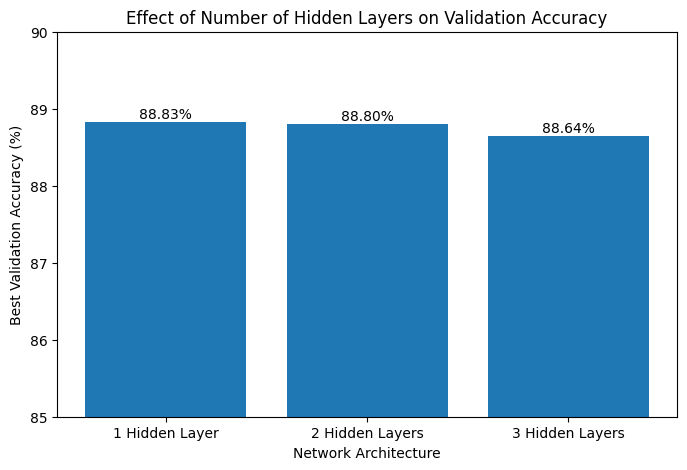

In [ ]:
# Compare validation accuracy for 1, 2, and 3 hidden layers

layer_names = ["1 Hidden Layer", "2 Hidden Layers", "3 Hidden Layers"]

layer_accuracies = [
    best_val_acc_1layer * 100,
    best_val_acc * 100,
    best_val_acc_3layer * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(layer_names, layer_accuracies)

plt.title("Effect of Number of Hidden Layers on Validation Accuracy")
plt.xlabel("Network Architecture")
plt.ylabel("Best Validation Accuracy (%)")
plt.ylim(85, 90)

# Add accuracy values above bars
for bar, value in zip(bars, layer_accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.05,
        f"{value:.2f}%",
        ha="center")

plt.show()

## 4. Effect of Number of Hidden Units

In [ ]:
# Model with TWO hidden layers and 8 units per layer
model_8units = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")])

model_8units.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model_8units.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 8)              │        80,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,089 (312.85 KB)

 Trainable params: 80,089 (312.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with 8 units per hidden layer
history_8units = model_8units.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.7695 - loss: 0.5644 - val_accuracy: 0.8577 - val_loss: 0.4593
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8859 - loss: 0.3875 - val_accuracy: 0.8731 - val_loss: 0.3653
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9075 - loss: 0.2995 - val_accuracy: 0.8845 - val_loss: 0.3162
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9222 - loss: 0.2455 - val_accuracy: 0.8846 - val_loss: 0.2971
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9343 - loss: 0.2091 - val_accuracy: 0.8896 - val_loss: 0.2801
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9443 - loss: 0.1811 - val_accuracy: 0.8824 - val_loss: 0.2903
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9504 - loss: 0.1601 - val_accuracy: 0.8881 - val_loss: 0.2791
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9569 - loss: 0.1422 - val_accuracy: 0.8869 - v

In [ ]:
# Get validation results for the 8-unit model
val_accuracy_8units = history_8units.history["val_accuracy"]
val_loss_8units = history_8units.history["val_loss"]

best_epoch_8units = np.argmax(val_accuracy_8units) + 1
best_val_acc_8units = np.max(val_accuracy_8units)

best_loss_epoch_8units = np.argmin(val_loss_8units) + 1
best_val_loss_8units = np.min(val_loss_8units)

print("8-unit model")
print(f"Best validation accuracy: {best_val_acc_8units:.4f} "
      f"({best_val_acc_8units*100:.2f}%) at epoch {best_epoch_8units}")

print(f"Lowest validation loss: {best_val_loss_8units:.4f} "
      f"at epoch {best_loss_epoch_8units}")

8-unit model
Best validation accuracy: 0.8896 (88.96%) at epoch 5
Lowest validation loss: 0.2791 at epoch 7


In [ ]:
# Model with TWO hidden layers and 32 units per layer
model_32units = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")])

model_32units.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model_32units.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │       320,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,121 (1.22 MB)

 Trainable params: 321,121 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with 32 units per hidden layer
history_32units = model_32units.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.7659 - loss: 0.5151 - val_accuracy: 0.8415 - val_loss: 0.3941
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8919 - loss: 0.3030 - val_accuracy: 0.8763 - val_loss: 0.3140
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9203 - loss: 0.2288 - val_accuracy: 0.8441 - val_loss: 0.3737
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9340 - loss: 0.1873 - val_accuracy: 0.8742 - val_loss: 0.3155
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9439 - loss: 0.1585 - val_accuracy: 0.8826 - val_loss: 0.3026
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9563 - loss: 0.1328 - val_accuracy: 0.8560 - val_loss: 0.3794
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9583 - loss: 0.1175 - val_accuracy: 0.8806 - val_loss: 0.3086
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9679 - loss: 0.0990 - val_accuracy: 0.8721 - v

In [ ]:
# Get validation results for the 32-unit model
val_accuracy_32units = history_32units.history["val_accuracy"]
val_loss_32units = history_32units.history["val_loss"]

best_epoch_32units = np.argmax(val_accuracy_32units) + 1
best_val_acc_32units = np.max(val_accuracy_32units)

best_loss_epoch_32units = np.argmin(val_loss_32units) + 1
best_val_loss_32units = np.min(val_loss_32units)

print("32-unit model")
print(f"Best validation accuracy: {best_val_acc_32units:.4f} "
      f"({best_val_acc_32units*100:.2f}%) at epoch {best_epoch_32units}")

print(f"Lowest validation loss: {best_val_loss_32units:.4f} "
      f"at epoch {best_loss_epoch_32units}")

32-unit model
Best validation accuracy: 0.8826 (88.26%) at epoch 5
Lowest validation loss: 0.3026 at epoch 5


In [ ]:
# Model with TWO hidden layers and 64 units per layer
model_64units = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")])

model_64units.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model_64units.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,289 (2.46 MB)

 Trainable params: 644,289 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with 64 units per hidden layer
history_64units = model_64units.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.7570 - loss: 0.5067 - val_accuracy: 0.8572 - val_loss: 0.3610
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8877 - loss: 0.2940 - val_accuracy: 0.8733 - val_loss: 0.3115
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.9197 - loss: 0.2146 - val_accuracy: 0.8816 - val_loss: 0.2908
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9324 - loss: 0.1781 - val_accuracy: 0.8859 - val_loss: 0.2811
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9461 - loss: 0.1472 - val_accuracy: 0.8798 - val_loss: 0.3180
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9588 - loss: 0.1176 - val_accuracy: 0.8462 - val_loss: 0.4312
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.9720 - loss: 0.0863 - val_accuracy: 0.8820 - val_loss: 0.3324
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9729 - loss: 0.0800 - val_accuracy: 0.8758 - 

In [ ]:
# Get validation results for the 64-unit model
val_accuracy_64units = history_64units.history["val_accuracy"]
val_loss_64units = history_64units.history["val_loss"]

best_epoch_64units = np.argmax(val_accuracy_64units) + 1
best_val_acc_64units = np.max(val_accuracy_64units)

best_loss_epoch_64units = np.argmin(val_loss_64units) + 1
best_val_loss_64units = np.min(val_loss_64units)

print("64-unit model")
print(f"Best validation accuracy: {best_val_acc_64units:.4f} "
      f"({best_val_acc_64units*100:.2f}%) at epoch {best_epoch_64units}")

print(f"Lowest validation loss: {best_val_loss_64units:.4f} "
      f"at epoch {best_loss_epoch_64units}")

64-unit model
Best validation accuracy: 0.8859 (88.59%) at epoch 4
Lowest validation loss: 0.2811 at epoch 4


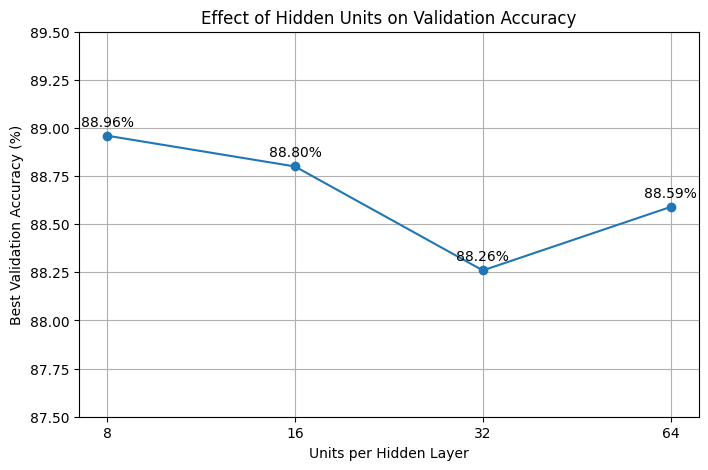

In [ ]:
# Compare the effect of hidden units on validation accuracy

unit_labels = ["8", "16", "32", "64"]

unit_accuracies = [
    best_val_acc_8units * 100,
    best_val_acc * 100,
    best_val_acc_32units * 100,
    best_val_acc_64units * 100
]

plt.figure(figsize=(8, 5))
plt.plot(unit_labels, unit_accuracies, marker="o")

plt.title("Effect of Hidden Units on Validation Accuracy")
plt.xlabel("Units per Hidden Layer")
plt.ylabel("Best Validation Accuracy (%)")
plt.ylim(87.5, 89.5)
plt.grid(True)

for x, y in zip(unit_labels, unit_accuracies):
    plt.text(x, y + 0.05, f"{y:.2f}%", ha="center")

plt.show()

In [ ]:
import pandas as pd

units_results = pd.DataFrame({
    "Units per Hidden Layer": [8, 16, 32, 64],
    "Best Validation Accuracy (%)": [
        best_val_acc_8units * 100,
        best_val_acc * 100,
        best_val_acc_32units * 100,
        best_val_acc_64units * 100],
    "Best Accuracy Epoch": [
        best_epoch_8units,
        best_epoch_acc,
        best_epoch_32units,
        best_epoch_64units],
    "Lowest Validation Loss": [
        best_val_loss_8units,
        best_val_loss,
        best_val_loss_32units,
        best_val_loss_64units ]})

units_results.round(4)

,Units per Hidden Layer,Best Validation Accuracy (%),Best Accuracy Epoch,Lowest Validation Loss
0,8,88.96,5,0.2791
1,16,88.80,4,0.2790
2,32,88.26,5,0.3026
3,64,88.59,4,0.2811


## 5. Effect of Loss Function

In [ ]:
# Baseline architecture using MSE loss
model_mse = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")])

model_mse.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["accuracy"])

model_mse.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model using MSE loss
history_mse = model_mse.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.7614 - loss: 0.1857 - val_accuracy: 0.8577 - val_loss: 0.1314
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8890 - loss: 0.1044 - val_accuracy: 0.8677 - val_loss: 0.1065
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9115 - loss: 0.0794 - val_accuracy: 0.8860 - val_loss: 0.0894
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9313 - loss: 0.0633 - val_accuracy: 0.8731 - val_loss: 0.0928
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9391 - loss: 0.0545 - val_accuracy: 0.8812 - val_loss: 0.0873
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9509 - loss: 0.0464 - val_accuracy: 0.8866 - val_loss: 0.0849
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9571 - loss: 0.0411 - val_accuracy: 0.8847 - val_loss: 0.0842
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9629 - loss: 0.0364 - val_accuracy: 0.8834 - v

In [ ]:
# Get validation results for the MSE model
val_accuracy_mse = history_mse.history["val_accuracy"]
val_loss_mse = history_mse.history["val_loss"]

best_epoch_mse = np.argmax(val_accuracy_mse) + 1
best_val_acc_mse = np.max(val_accuracy_mse)

best_loss_epoch_mse = np.argmin(val_loss_mse) + 1
best_val_loss_mse = np.min(val_loss_mse)

print("MSE loss model")
print(f"Best validation accuracy: {best_val_acc_mse:.4f} "
      f"({best_val_acc_mse*100:.2f}%) at epoch {best_epoch_mse}")

print(f"Lowest validation loss: {best_val_loss_mse:.4f} "
      f"at epoch {best_loss_epoch_mse}")

MSE loss model
Best validation accuracy: 0.8866 (88.66%) at epoch 6
Lowest validation loss: 0.0842 at epoch 7


## 6. Effect of Activation Function

In [ ]:
# Baseline architecture using tanh activation
model_tanh = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(16, activation="tanh"),
    keras.layers.Dense(16, activation="tanh"),
    keras.layers.Dense(1, activation="sigmoid")])

model_tanh.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model_tanh.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model using tanh activation
history_tanh = model_tanh.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.7883 - loss: 0.5007 - val_accuracy: 0.8559 - val_loss: 0.3840
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9018 - loss: 0.2932 - val_accuracy: 0.8833 - val_loss: 0.2953
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9229 - loss: 0.2175 - val_accuracy: 0.8899 - val_loss: 0.2706
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9436 - loss: 0.1653 - val_accuracy: 0.8883 - val_loss: 0.2751
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9526 - loss: 0.1371 - val_accuracy: 0.8850 - val_loss: 0.2977
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9616 - loss: 0.1127 - val_accuracy: 0.8815 - val_loss: 0.3173
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9719 - loss: 0.0899 - val_accuracy: 0.8771 - val_loss: 0.3449
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9771 - loss: 0.0722 - val_accuracy: 0.8773 - 

In [ ]:
# Get validation results for the tanh model
val_accuracy_tanh = history_tanh.history["val_accuracy"]
val_loss_tanh = history_tanh.history["val_loss"]

best_epoch_tanh = np.argmax(val_accuracy_tanh) + 1
best_val_acc_tanh = np.max(val_accuracy_tanh)

best_loss_epoch_tanh = np.argmin(val_loss_tanh) + 1
best_val_loss_tanh = np.min(val_loss_tanh)

print("TANH activation model")
print(f"Best validation accuracy: {best_val_acc_tanh:.4f} "
      f"({best_val_acc_tanh*100:.2f}%) at epoch {best_epoch_tanh}")

print(f"Lowest validation loss: {best_val_loss_tanh:.4f} "
      f"at epoch {best_loss_epoch_tanh}")

TANH activation model
Best validation accuracy: 0.8899 (88.99%) at epoch 3
Lowest validation loss: 0.2706 at epoch 3


## 7. Effect of Dropout Regularization

In [ ]:
# Baseline architecture with dropout regularization
model_dropout = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation="sigmoid")])

model_dropout.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model_dropout.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model with dropout
history_dropout = model_dropout.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.6221 - loss: 0.6477 - val_accuracy: 0.8238 - val_loss: 0.5557
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7608 - loss: 0.5352 - val_accuracy: 0.8293 - val_loss: 0.4656
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8223 - loss: 0.4489 - val_accuracy: 0.8690 - val_loss: 0.3884
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8584 - loss: 0.3850 - val_accuracy: 0.8691 - val_loss: 0.3483
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8860 - loss: 0.3320 - val_accuracy: 0.8754 - val_loss: 0.3211
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9011 - loss: 0.2958 - val_accuracy: 0.8871 - val_loss: 0.2831
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9159 - loss: 0.2595 - val_accuracy: 0.8841 - val_loss: 0.2798
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9253 - loss: 0.2315 - val_accuracy: 0.8845 - v

In [ ]:
# Get validation results for the dropout model
val_accuracy_dropout = history_dropout.history["val_accuracy"]
val_loss_dropout = history_dropout.history["val_loss"]

best_epoch_dropout = np.argmax(val_accuracy_dropout) + 1
best_val_acc_dropout = np.max(val_accuracy_dropout)

best_loss_epoch_dropout = np.argmin(val_loss_dropout) + 1
best_val_loss_dropout = np.min(val_loss_dropout)

print("DROPOUT model")
print(f"Best validation accuracy: {best_val_acc_dropout:.4f} "
      f"({best_val_acc_dropout*100:.2f}%) at epoch {best_epoch_dropout}")

print(f"Lowest validation loss: {best_val_loss_dropout:.4f} "
      f"at epoch {best_loss_epoch_dropout}")

DROPOUT model
Best validation accuracy: 0.8871 (88.71%) at epoch 6
Lowest validation loss: 0.2794 at epoch 8


In [ ]:
# Baseline architecture with 20% dropout
model_dropout02 = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid")])

model_dropout02.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model_dropout02.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_dropout02 = model_dropout02.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.7133 - loss: 0.5837 - val_accuracy: 0.8501 - val_loss: 0.4559
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8457 - loss: 0.4115 - val_accuracy: 0.8767 - val_loss: 0.3425
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8849 - loss: 0.3188 - val_accuracy: 0.8859 - val_loss: 0.2957
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9119 - loss: 0.2565 - val_accuracy: 0.8892 - val_loss: 0.2775
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9225 - loss: 0.2196 - val_accuracy: 0.8866 - val_loss: 0.2832
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9393 - loss: 0.1824 - val_accuracy: 0.8846 - val_loss: 0.2865
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9491 - loss: 0.1557 - val_accuracy: 0.8854 - val_loss: 0.2881
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9555 - loss: 0.1380 - val_accuracy: 0.8819 - v

In [ ]:
val_accuracy_dropout02 = history_dropout02.history["val_accuracy"]
val_loss_dropout02 = history_dropout02.history["val_loss"]

best_epoch_dropout02 = np.argmax(val_accuracy_dropout02) + 1
best_val_acc_dropout02 = np.max(val_accuracy_dropout02)

best_loss_epoch_dropout02 = np.argmin(val_loss_dropout02) + 1
best_val_loss_dropout02 = np.min(val_loss_dropout02)

print("DROPOUT 0.2 model")
print(f"Best validation accuracy: {best_val_acc_dropout02:.4f} "
      f"({best_val_acc_dropout02*100:.2f}%) at epoch {best_epoch_dropout02}")

print(f"Lowest validation loss: {best_val_loss_dropout02:.4f} "
      f"at epoch {best_loss_epoch_dropout02}")

DROPOUT 0.2 model
Best validation accuracy: 0.8892 (88.92%) at epoch 4
Lowest validation loss: 0.2775 at epoch 4


## 8. Combined Model

In [ ]:
# Combined candidate model based on previous experiments
model_combined = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(8, activation="tanh"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(8, activation="tanh"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid")])

model_combined.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

model_combined.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 8)              │        80,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,089 (312.85 KB)

 Trainable params: 80,089 (312.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_combined = model_combined.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.7689 - loss: 0.5445 - val_accuracy: 0.8601 - val_loss: 0.4298
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8871 - loss: 0.3696 - val_accuracy: 0.8712 - val_loss: 0.3453
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9092 - loss: 0.2830 - val_accuracy: 0.8885 - val_loss: 0.2944
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9275 - loss: 0.2303 - val_accuracy: 0.8869 - val_loss: 0.2784
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9409 - loss: 0.1898 - val_accuracy: 0.8896 - val_loss: 0.2692
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9530 - loss: 0.1576 - val_accuracy: 0.8871 - val_loss: 0.2821
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9619 - loss: 0.1344 - val_accuracy: 0.8848 - val_loss: 0.2855
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9669 - loss: 0.1159 - val_accuracy: 0.8765 - v

In [ ]:
val_accuracy_combined = history_combined.history["val_accuracy"]
val_loss_combined = history_combined.history["val_loss"]

best_epoch_combined = np.argmax(val_accuracy_combined) + 1
best_val_acc_combined = np.max(val_accuracy_combined)

best_loss_epoch_combined = np.argmin(val_loss_combined) + 1
best_val_loss_combined = np.min(val_loss_combined)

print("COMBINED candidate model")
print(f"Best validation accuracy: {best_val_acc_combined:.4f} "
      f"({best_val_acc_combined*100:.2f}%) at epoch {best_epoch_combined}")

print(f"Lowest validation loss: {best_val_loss_combined:.4f} "
      f"at epoch {best_loss_epoch_combined}")

COMBINED candidate model
Best validation accuracy: 0.8896 (88.96%) at epoch 5
Lowest validation loss: 0.2692 at epoch 5


## 9. Comparison of All Models

In [ ]:
# Summary of all experiments

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "1 Hidden Layer",
        "3 Hidden Layers",
        "8 Units",
        "32 Units",
        "64 Units",
        "MSE Loss",
        "Tanh Activation",
        "Dropout 0.2",
        "Dropout 0.5",
        "Combined Model"
    ],

    "Hidden Layers": [
        2, 1, 3, 2, 2, 2, 2, 2, 2, 2, 2
    ],

    "Units": [
        "16-16",
        "16",
        "16-16-16",
        "8-8",
        "32-32",
        "64-64",
        "16-16",
        "16-16",
        "16-16",
        "16-16",
        "8-8"
    ],

    "Activation": [
        "ReLU",
        "ReLU",
        "ReLU",
        "ReLU",
        "ReLU",
        "ReLU",
        "ReLU",
        "Tanh",
        "ReLU",
        "ReLU",
        "Tanh"
    ],

    "Loss": [
        "Binary Crossentropy",
        "Binary Crossentropy",
        "Binary Crossentropy",
        "Binary Crossentropy",
        "Binary Crossentropy",
        "Binary Crossentropy",
        "MSE",
        "Binary Crossentropy",
        "Binary Crossentropy",
        "Binary Crossentropy",
        "Binary Crossentropy"
    ],

    "Dropout": [
        0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0.5, 0.2
    ],

    "Best Validation Accuracy (%)": [
        best_val_acc * 100,
        best_val_acc_1layer * 100,
        best_val_acc_3layer * 100,
        best_val_acc_8units * 100,
        best_val_acc_32units * 100,
        best_val_acc_64units * 100,
        best_val_acc_mse * 100,
        best_val_acc_tanh * 100,
        best_val_acc_dropout02 * 100,
        best_val_acc_dropout * 100,
        best_val_acc_combined * 100
    ],

    "Best Accuracy Epoch": [
        best_epoch_acc,
        best_epoch_1layer,
        best_epoch_3layer,
        best_epoch_8units,
        best_epoch_32units,
        best_epoch_64units,
        best_epoch_mse,
        best_epoch_tanh,
        best_epoch_dropout02,
        best_epoch_dropout,
        best_epoch_combined
    ]
})

results.round(2)

,Model,Hidden Layers,Units,Activation,Loss,Dropout,Best Validation Accuracy (%),Best Accuracy Epoch
0,Baseline,2,16-16,ReLU,Binary Crossentropy,0.0,88.80,4
1,1 Hidden Layer,1,16,ReLU,Binary Crossentropy,0.0,88.83,3
2,3 Hidden Layers,3,16-16-16,ReLU,Binary Crossentropy,0.0,88.64,5
3,8 Units,2,8-8,ReLU,Binary Crossentropy,0.0,88.96,5
4,32 Units,2,32-32,ReLU,Binary Crossentropy,0.0,88.26,5
5,64 Units,2,64-64,ReLU,Binary Crossentropy,0.0,88.59,4
6,MSE Loss,2,16-16,ReLU,MSE,0.0,88.66,6
7,Tanh Activation,2,16-16,Tanh,Binary Crossentropy,0.0,88.99,3
8,Dropout 0.2,2,16-16,ReLU,Binary Crossentropy,0.2,88.92,4
9,Dropout 0.5,2,16-16,ReLU,Binary Crossentropy,0.5,88.71,6


In [ ]:
# Sort models from highest to lowest validation accuracy
results_sorted = results.sort_values(
    by="Best Validation Accuracy (%)",
    ascending=False
).reset_index(drop=True)

results_sorted.round(2)

,Model,Hidden Layers,Units,Activation,Loss,Dropout,Best Validation Accuracy (%),Best Accuracy Epoch
0,Tanh Activation,2,16-16,Tanh,Binary Crossentropy,0.0,88.99,3
1,8 Units,2,8-8,ReLU,Binary Crossentropy,0.0,88.96,5
2,Combined Model,2,8-8,Tanh,Binary Crossentropy,0.2,88.96,5
3,Dropout 0.2,2,16-16,ReLU,Binary Crossentropy,0.2,88.92,4
4,1 Hidden Layer,1,16,ReLU,Binary Crossentropy,0.0,88.83,3
5,Baseline,2,16-16,ReLU,Binary Crossentropy,0.0,88.80,4
6,Dropout 0.5,2,16-16,ReLU,Binary Crossentropy,0.5,88.71,6
7,MSE Loss,2,16-16,ReLU,MSE,0.0,88.66,6
8,3 Hidden Layers,3,16-16-16,ReLU,Binary Crossentropy,0.0,88.64,5
9,64 Units,2,64-64,ReLU,Binary Crossentropy,0.0,88.59,4


## 10. Repeated-Seed Analysis

In [ ]:
# Function to repeat a model using different random seeds

def run_model(units=16, activation="relu", dropout=0.0, seed=1):

    # Set random seed for reproducibility
    keras.utils.set_random_seed(seed)

    model = keras.Sequential([
        keras.layers.Input(shape=(10000,)),
        keras.layers.Dense(units, activation=activation),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(units, activation=activation),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1, activation="sigmoid")])

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"])

    history = model.fit(
        partial_x_train,
        partial_y_train,
        epochs=20,
        batch_size=512,
        validation_data=(x_val, y_val),
        verbose=0)

    best_accuracy = max(history.history["val_accuracy"])
    best_epoch = np.argmax(history.history["val_accuracy"]) + 1

    return best_accuracy, best_epoch

In [ ]:
seeds = [1, 2, 3]

repeat_results = []

for seed in seeds:

    # Tanh model: 16-16
    acc, epoch = run_model(
        units=16,
        activation="tanh",
        dropout=0.0,
        seed=seed)

    repeat_results.append([
        "Tanh 16-16",
        seed,
        acc * 100,
        epoch])

    # ReLU model: 8-8
    acc, epoch = run_model(
        units=8,
        activation="relu",
        dropout=0.0,
        seed=seed)

    repeat_results.append([
        "ReLU 8-8",
        seed,
        acc * 100,
        epoch])

    # Combined model
    acc, epoch = run_model(
        units=8,
        activation="tanh",
        dropout=0.2,
        seed=seed )

    repeat_results.append([
        "Tanh 8-8 + Dropout 0.2",
        seed,
        acc * 100,
        epoch])

repeat_df = pd.DataFrame(
    repeat_results,
    columns=[
        "Model",
        "Seed",
        "Best Validation Accuracy (%)",
        "Best Epoch" ])

repeat_df.round(2)

,Model,Seed,Best Validation Accuracy (%),Best Epoch
0,Tanh 16-16,1,88.92,4
1,ReLU 8-8,1,88.77,8
2,Tanh 8-8 + Dropout 0.2,1,88.98,5
3,Tanh 16-16,2,88.72,3
4,ReLU 8-8,2,88.71,6
5,Tanh 8-8 + Dropout 0.2,2,88.89,5
6,Tanh 16-16,3,88.70,2
7,ReLU 8-8,3,88.95,5
8,Tanh 8-8 + Dropout 0.2,3,89.03,4


In [ ]:
summary_repeat = repeat_df.groupby("Model").agg(
    Mean_Validation_Accuracy=("Best Validation Accuracy (%)", "mean"),
    SD_Validation_Accuracy=("Best Validation Accuracy (%)", "std"),
    Mean_Best_Epoch=("Best Epoch", "mean")
).reset_index()

summary_repeat.round(3)

,Model,Mean_Validation_Accuracy,SD_Validation_Accuracy,Mean_Best_Epoch
0,ReLU 8-8,88.810,0.125,6.333
1,Tanh 16-16,88.780,0.122,3.000
2,Tanh 8-8 + Dropout 0.2,88.967,0.071,4.667


## 11. Final Model and Test Evaluation

In [ ]:
# Set seed for reproducibility
keras.utils.set_random_seed(1)

# Build the selected final model
final_model = keras.Sequential([
    keras.layers.Input(shape=(10000,)),
    keras.layers.Dense(8, activation="tanh"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(8, activation="tanh"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid")])

final_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"])

final_model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 8)              │        80,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,089 (312.85 KB)

 Trainable params: 80,089 (312.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the final selected model using all training data
# Five epochs were selected based on validation experiments

history_final = final_model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=512,
    verbose=1)

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8116 - loss: 0.4922
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8971 - loss: 0.3187
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9198 - loss: 0.2446
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9336 - loss: 0.2013
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9448 - loss: 0.1729


In [ ]:
# Evaluate the final model on the untouched test set

test_loss, test_accuracy = final_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("FINAL TEST RESULTS")
print(f"Test accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test loss: {test_loss:.4f}")

FINAL TEST RESULTS
Test accuracy: 0.8805 (88.05%)
Test loss: 0.3005
